In [1]:
!pip install alibi

INFO: pip is looking at multiple versions of thinc to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of thinc to determine which version is compatible with other requirements. This could take a while.
INFO: This is taking longer than usual. You might need to provide the dependency resolver with stricter constraints to reduce runtime. See https://pip.pypa.io/warnings/backtracking for guidance. If you want to abort this run, press Ctrl + C.
INFO: pip is looking at multiple versions of spacy[lookups] to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 522.1/522.1 kB 11.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.8/60.8 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 30.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.4/119.4 kB 9.3 MB/s eta 0:00:00

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import learning_curve
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, BatchNormalization, LSTM
from tensorflow.keras.layers import Flatten, Dropout, Dense
from sklearn.inspection import permutation_importance



Exception ignored in: <function WeakSet.__init__.<locals>._remove at 0x7aeceb955080>
Traceback (most recent call last):
  File "/usr/lib/python3.11/_weakrefset.py", line 39, in _remove
    def _remove(item, selfref=ref(self)):

KeyboardInterrupt: 


In [2]:
df=pd.read_csv('cardio_train.csv',sep=";")
df

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
69995,99993,19240,2,168,76.0,120,80,1,1,1,0,1,0
69996,99995,22601,1,158,126.0,140,90,2,2,0,0,1,1
69997,99996,19066,2,183,105.0,180,90,3,1,0,1,0,1
69998,99998,22431,1,163,72.0,135,80,1,2,0,0,0,1


In [3]:
df.duplicated().sum()

0

In [ ]:
df.isnull().sum()

,0
id,0
age,0
gender,0
height,0
weight,0
ap_hi,0
ap_lo,0
cholesterol,0
gluc,0
smoke,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           70000 non-null  int64  
 1   age          70000 non-null  int64  
 2   gender       70000 non-null  int64  
 3   height       70000 non-null  int64  
 4   weight       70000 non-null  float64
 5   ap_hi        70000 non-null  int64  
 6   ap_lo        70000 non-null  int64  
 7   cholesterol  70000 non-null  int64  
 8   gluc         70000 non-null  int64  
 9   smoke        70000 non-null  int64  
 10  alco         70000 non-null  int64  
 11  active       70000 non-null  int64  
 12  cardio       70000 non-null  int64  
dtypes: float64(1), int64(12)
memory usage: 6.9 MB


In [ ]:
df.describe()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
count,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000
mean,49972.419900,19468.865814,1.349571,164.359229,74.205690,128.817286,96.630414,1.366871,1.226457,0.088129,0.053771,0.803729,0.499700
std,28851.302323,2467.251667,0.476838,8.210126,14.395757,154.011419,188.472530,0.680250,0.572270,0.283484,0.225568,0.397179,0.500003
min,0.000000,10798.000000,1.000000,55.000000,10.000000,-150.000000,-70.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,25006.750000,17664.000000,1.000000,159.000000,65.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
50%,50001.500000,19703.000000,1.000000,165.000000,72.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
75%,74889.250000,21327.000000,2.000000,170.000000,82.000000,140.000000,90.000000,2.000000,1.000000,0.000000,0.000000,1.000000,1.000000
max,99999.000000,23713.000000,2.000000,250.000000,200.000000,16020.000000,11000.000000,3.000000,3.000000,1.000000,1.000000,1.000000,1.000000


In [4]:
df['age'] = df['age']/ 365

In [5]:
df.drop("id",axis=1,inplace= True)

In [ ]:
df

,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,50.391781,2,168,62.0,110,80,1,1,0,0,1,0
1,55.419178,1,156,85.0,140,90,3,1,0,0,1,1
2,51.663014,1,165,64.0,130,70,3,1,0,0,0,1
3,48.282192,2,169,82.0,150,100,1,1,0,0,1,1
4,47.873973,1,156,56.0,100,60,1,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
69995,52.712329,2,168,76.0,120,80,1,1,1,0,1,0
69996,61.920548,1,158,126.0,140,90,2,2,0,0,1,1
69997,52.235616,2,183,105.0,180,90,3,1,0,1,0,1
69998,61.454795,1,163,72.0,135,80,1,2,0,0,0,1


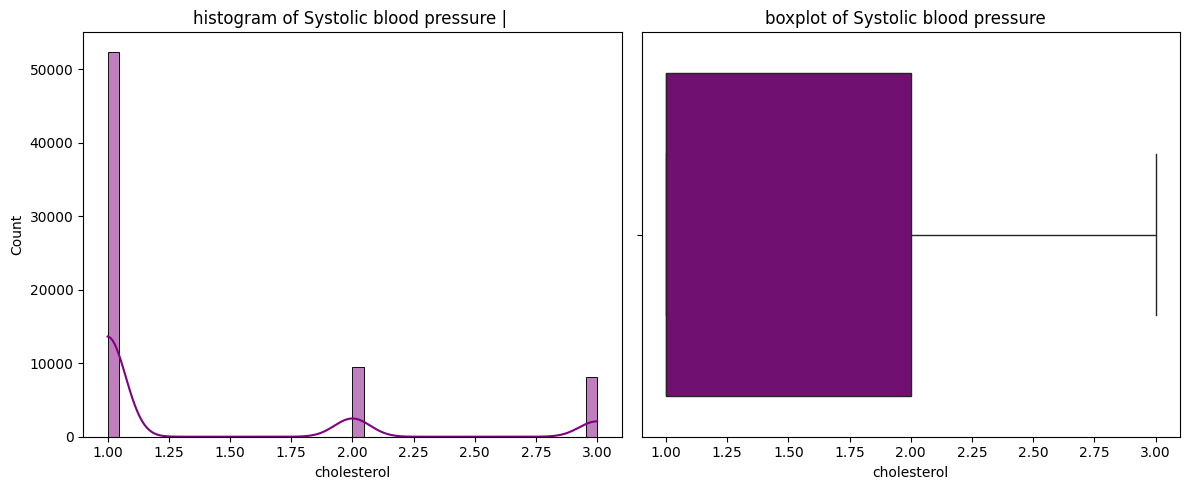

In [ ]:
plt.figure(figsize=(12, 5))


plt.subplot(1, 2, 1)
sns.histplot(df['cholesterol'], kde=True, color='purple')
plt.title("histogram of Systolic blood pressure | " )

plt.subplot(1, 2, 2)
sns.boxplot(x=df['cholesterol'], color='purple')
plt.title("boxplot of Systolic blood pressure  " )

plt.tight_layout()
plt.show()

In [6]:
x= df.drop(['cardio'], axis=1)
y= df['cardio']


In [7]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, accuracy_score,classification_report


In [8]:
scaler = StandardScaler()
for col in x.columns:
    if x[col].dtype != 'object':
        x[col] = scaler.fit_transform(x[[col]])

In [9]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=0)

In [10]:
svmwith_linear = SVC(kernel='linear', C=0.3)
svmwith_linear.fit(x_train, y_train)


SVC(C=0.3, kernel='linear')

/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
6 fits failed out of a total of 25.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
6 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.11/dist-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/sklearn/svm/_base.py", line 207, in fit
    y = self._validate_targets(y)
        

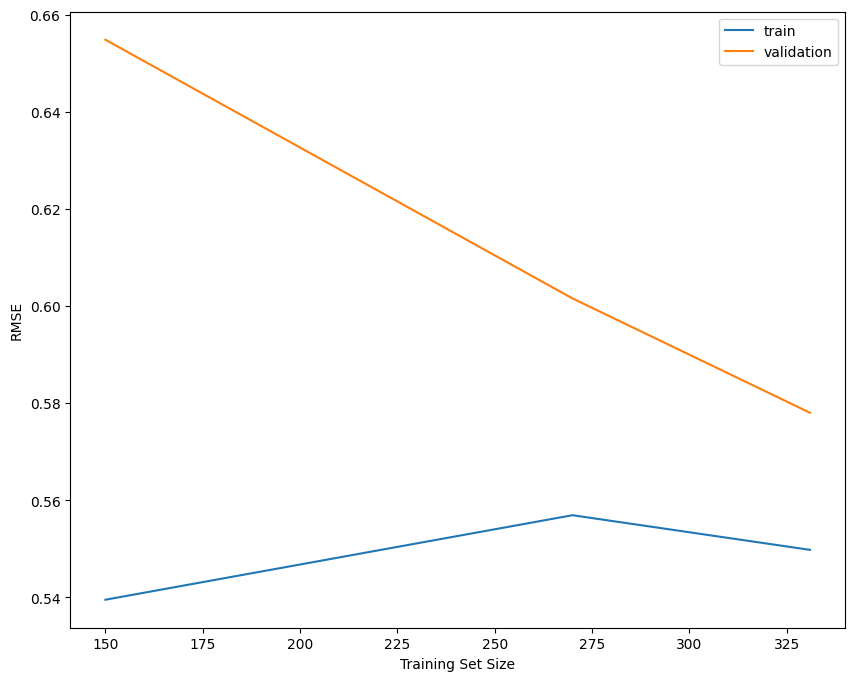

In [ ]:
train_sizes, train_scores, test_scores = learning_curve(
    estimator=svmwith_linear,
    X=x_train,
    y=y_train,
    cv=5,
    scoring="neg_root_mean_squared_error",
    train_sizes = [1, 75, 150, 270, 331]
)

train_mean = -train_scores.mean(axis=1)
test_mean = -test_scores.mean(axis=1)

plt.subplots(figsize=(10,8))
plt.plot(train_sizes, train_mean, label="train")
plt.plot(train_sizes, test_mean, label="validation")

plt.xlabel("Training Set Size")
plt.ylabel("RMSE")
plt.legend(loc="best")

plt.show();


In [11]:
y_trainPred=svmwith_linear.predict(x_train)
print("SVM modeL with linear kernel accuracy of train data:", accuracy_score(y_train, y_trainPred))


SVM modeL with linear kernel accuracy of train data: 0.7240535714285714


In [ ]:
yPred = svmwith_linear.predict(x_test)
print("SVM modeL with linear kernel accuracy of test data:", accuracy_score(y_test, yPred))


SVM modeL with linear kernel accuracy of test data: 0.7214285714285714


In [ ]:

print("___________________________train classification report_______________________________\n", classification_report(y_train, y_trainPred))

print("\n___________________________test classification report_______________________________\n", classification_report(y_test, yPred))


___________________________train classification report_______________________________
               precision    recall  f1-score   support

           0       0.69      0.81      0.75     27952
           1       0.77      0.64      0.70     28048

    accuracy                           0.72     56000
   macro avg       0.73      0.72      0.72     56000
weighted avg       0.73      0.72      0.72     56000


___________________________test classification report_______________________________
               precision    recall  f1-score   support

           0       0.69      0.81      0.75      7069
           1       0.77      0.63      0.69      6931

    accuracy                           0.72     14000
   macro avg       0.73      0.72      0.72     14000
weighted avg       0.73      0.72      0.72     14000



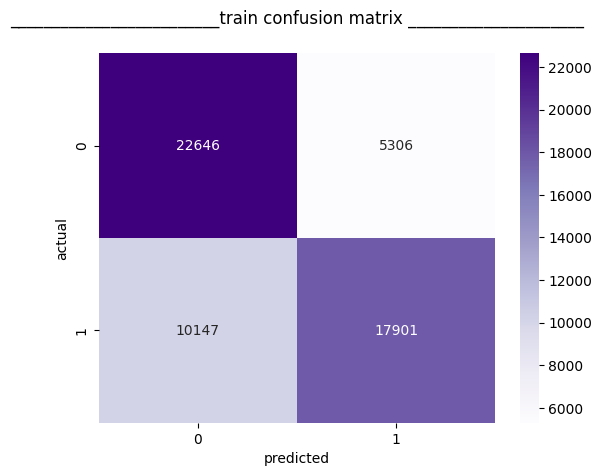

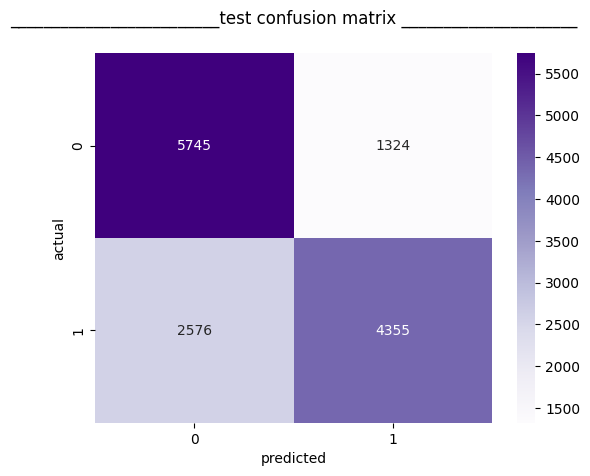

In [ ]:
sns.heatmap(confusion_matrix(y_train, y_trainPred), annot=True, fmt='d', cmap='Purples')
plt.title("_________________________train confusion matrix _____________________\n")
plt.xlabel("predicted")
plt.ylabel("actual")
plt.show()

print("\n")
sns.heatmap(confusion_matrix(y_test, yPred), annot=True, fmt='d', cmap='Purples')
plt.title("_________________________test confusion matrix _____________________\n")
plt.xlabel("predicted")
plt.ylabel("actual")
plt.show()


////////////////////////

In [17]:
svmwith_poly= SVC(kernel='poly', C=0.7)
svmwith_poly.fit(x_train, y_train)

SVC(C=0.7, kernel='poly')

In [ ]:
y_trainPredpoly=svmwith_poly.predict(x_train)
print("SVM modeL with linear kernel accuracy of train data:", accuracy_score(y_train, y_trainPredpoly))
yPredpoly= svmwith_poly.predict(x_test)
print("SVM modeL with linear kernel accuracy of test data:", accuracy_score(y_test, yPredpoly))


SVM modeL with linear kernel accuracy of train data: 0.6838214285714286
SVM modeL with linear kernel accuracy of test data: 0.6769285714285714


In [ ]:

print("___________________________train classification report_______________________________\n", classification_report(y_train, y_trainPredpoly))

print("\n___________________________test classification report_______________________________\n", classification_report(y_test, yPredpoly))


___________________________train classification report_______________________________
               precision    recall  f1-score   support

           0       0.64      0.82      0.72     27952
           1       0.75      0.55      0.63     28048

    accuracy                           0.68     56000
   macro avg       0.70      0.68      0.68     56000
weighted avg       0.70      0.68      0.68     56000


___________________________test classification report_______________________________
               precision    recall  f1-score   support

           0       0.64      0.82      0.72      7069
           1       0.75      0.53      0.62      6931

    accuracy                           0.68     14000
   macro avg       0.69      0.68      0.67     14000
weighted avg       0.69      0.68      0.67     14000



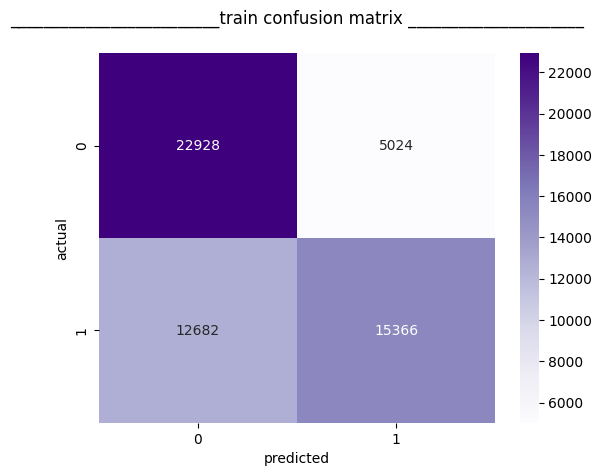

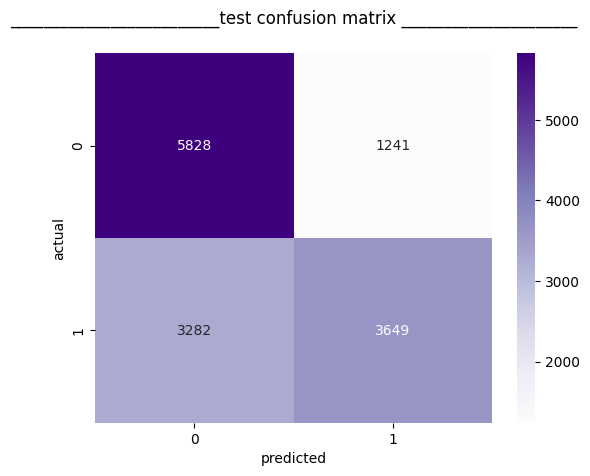

In [ ]:
sns.heatmap(confusion_matrix(y_train, y_trainPredpoly), annot=True, fmt='d', cmap='Purples')
plt.title("_________________________train confusion matrix _____________________\n")
plt.xlabel("predicted")
plt.ylabel("actual")
plt.show()

print("\n")
sns.heatmap(confusion_matrix(y_test, yPredpoly), annot=True, fmt='d', cmap='Purples')
plt.title("_________________________test confusion matrix _____________________\n")
plt.xlabel("predicted")
plt.ylabel("actual")
plt.show()


/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
6 fits failed out of a total of 25.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
6 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.11/dist-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/sklearn/svm/_base.py", line 207, in fit
    y = self._validate_targets(y)
        

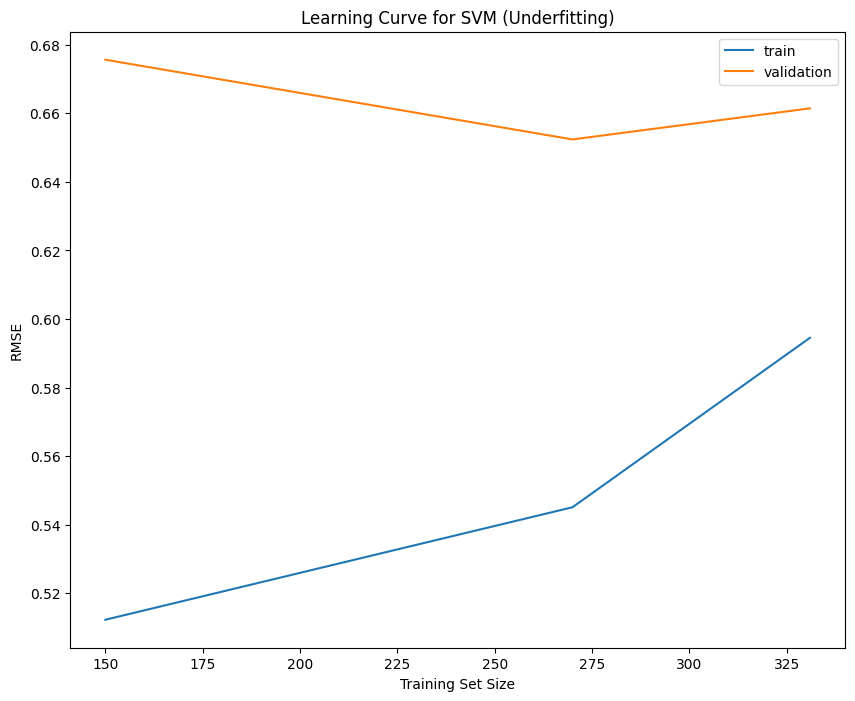

In [ ]:
train_sizes, train_scores, test_scores = learning_curve(
    estimator=svmwith_poly,
    X=x_train,
    y=y_train,
    cv=5,
    scoring="neg_root_mean_squared_error",
    train_sizes = [1, 75, 150, 270, 331]
)

train_mean = -train_scores.mean(axis=1)
test_mean = -test_scores.mean(axis=1)

plt.subplots(figsize=(10,8))
plt.plot(train_sizes, train_mean, label="train")
plt.plot(train_sizes, test_mean, label="validation")

plt.title("Learning Curve for SVM (Underfitting)")
plt.xlabel("Training Set Size")
plt.ylabel("RMSE")
plt.legend(loc="best")

plt.show()


In [ ]:
# from sklearn.datasets import make_hastie_10_2
# from sklearn.ensemble import GradientBoostingClassifier
# from sklearn.inspection import PartialDependenceDisplay
feature = ['age','gender',	'height',	'weight','ap_hi','ap_lo','cholesterol','gluc','smoke','alco'	,'active']
# PartialDependenceDisplay.from_estimator(
#     svmwith_linear,
#     x_test,
#     features=[0],
#     feature_names=feature,
#     response_method="decision_function",
# )


In [ ]:
from alibi.explainers import ALE , plot_ale

In [ ]:
dir(svmwith_linear)

['C',
 '__abstractmethods__',
 '__annotations__',
 '__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__setstate__',
 '__sizeof__',
 '__sklearn_clone__',
 '__sklearn_tags__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_abc_impl',
 '_build_request_for_signature',
 '_check_feature_names',
 '_check_n_features',
 '_check_proba',
 '_compute_kernel',
 '_decision_function',
 '_dense_decision_function',
 '_dense_fit',
 '_dense_predict',
 '_dense_predict_proba',
 '_doc_link_module',
 '_doc_link_template',
 '_doc_link_url_param_generator',
 '_dual_coef_',
 '_estimator_type',
 '_gamma',
 '_get_coef',
 '_get_default_requests',
 '_get_doc_link',
 '_get_metadata_request',
 '_get_param_names',
 '_get_tags',
 '_impl',
 '_inte

In [ ]:
x_test_df = pd.DataFrame(x_test, columns=feature)


In [ ]:
svmwith_linear = SVC(kernel='linear', C=0.3,probability=True)
svmwith_linear.fit(x_train, y_train)


SVC(C=0.3, kernel='linear', probability=True)

In [ ]:
print(x_test_df.columns)


Index(['age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol',
       'gluc', 'smoke', 'alco', 'active'],
      dtype='object')


In [ ]:
prob = svmwith_linear.predict_proba

ALEprob = ALE(prob, feature_names=feature, target_names=["No Disease", "Disease"])

exp = ALEprob.explain(x_test.values)



/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have va

TypeError: 'int' object is not iterable

array([[<Axes: xlabel='age', ylabel='ALE'>,
        <Axes: xlabel='gender', ylabel='ALE'>,
        <Axes: xlabel='height', ylabel='ALE'>],
       [<Axes: xlabel='weight', ylabel='ALE'>,
        <Axes: xlabel='ap_hi', ylabel='ALE'>,
        <Axes: xlabel='ap_lo', ylabel='ALE'>],
       [<Axes: xlabel='cholesterol', ylabel='ALE'>,
        <Axes: xlabel='gluc', ylabel='ALE'>,
        <Axes: xlabel='smoke', ylabel='ALE'>],
       [<Axes: xlabel='alco', ylabel='ALE'>,
        <Axes: xlabel='active', ylabel='ALE'>, None]], dtype=object)

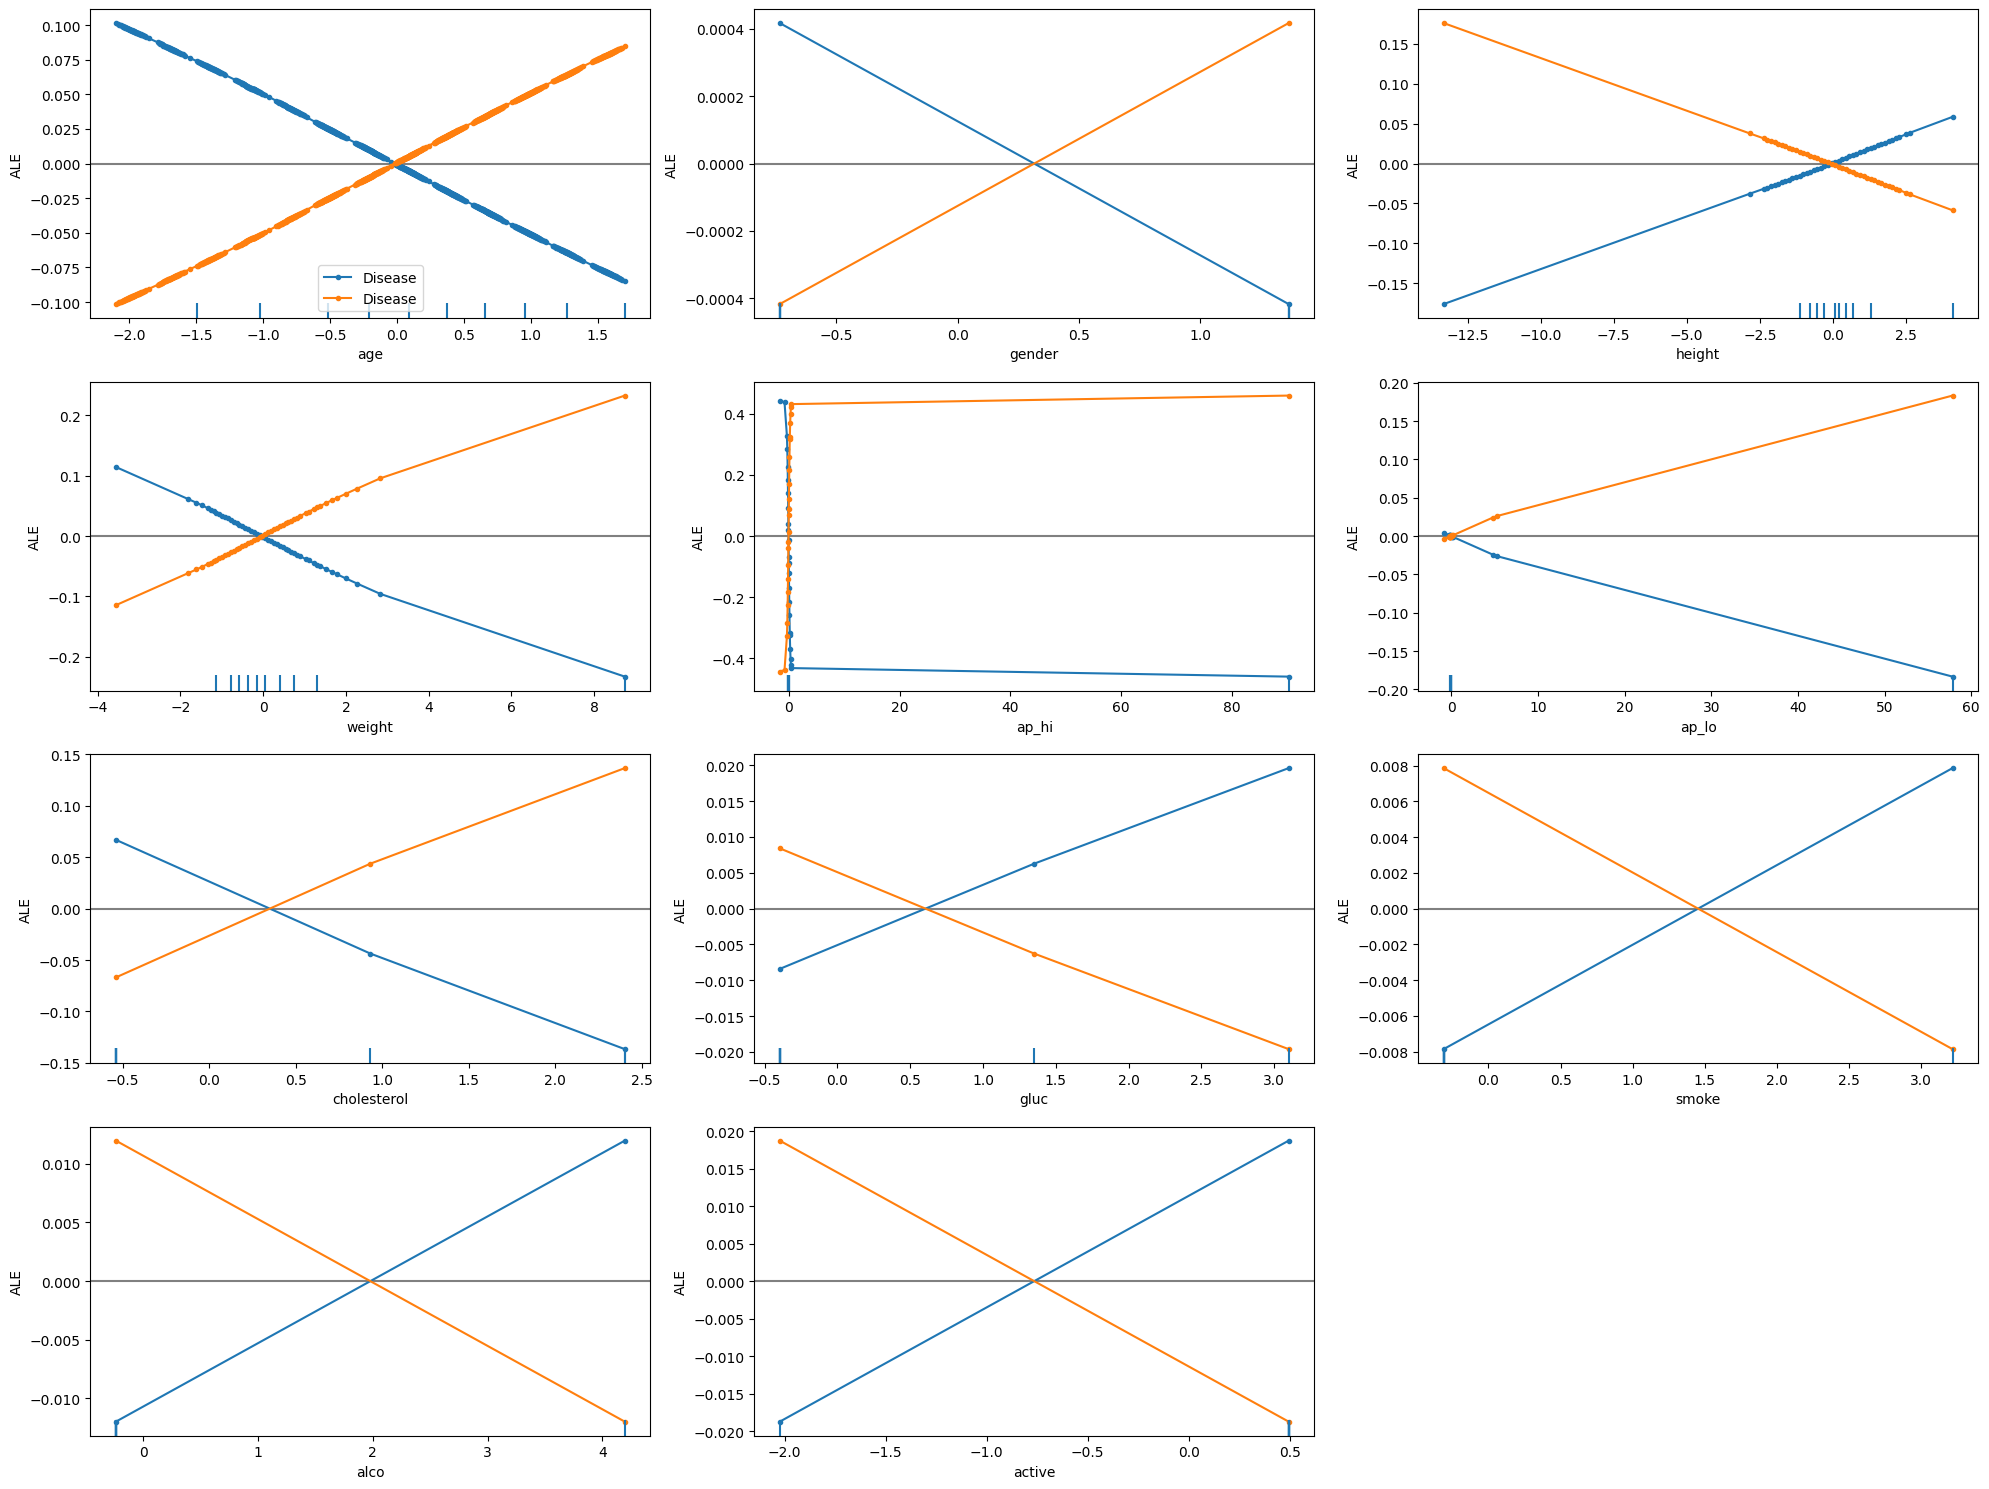

In [ ]:
plot_ale(exp,targets=[0,1],line_kw={"label": "Disease"},fig_kw={'figwidth': 20, 'figheight': 15},sharey=None)

In [ ]:
from sklearn.model_selection import validation_curve
import numpy as np

In [ ]:
def plot_validation_curve(estimator, title, X, y, param_name, param_range, cv=5, scoring="neg_root_mean_squared_error"):
    train_scores, test_scores = validation_curve(
        estimator=estimator,
        X=X,
        y=y,
        param_name=param_name,
        param_range=param_range,
        cv=cv,
        scoring=scoring
    )

    train_mean = -np.mean(train_scores, axis=1)
    test_mean = -np.mean(test_scores, axis=1)

    plt.figure(figsize=(10, 6))
    plt.plot(param_range, train_mean, label="Training score", color="blue")
    plt.plot(param_range, test_mean, label="Cross-validation score", color="red")

    plt.title(title)
    plt.xlabel(param_name)
    plt.ylabel("RMSE")
    plt.legend(loc="best")
    plt.grid()
    plt.show()
param_range = np.logspace(-3, 2, 10)
plot_validation_curve(svmwith_linear, "Validation Curve for SVM", x_train, y_train, "C", param_range)


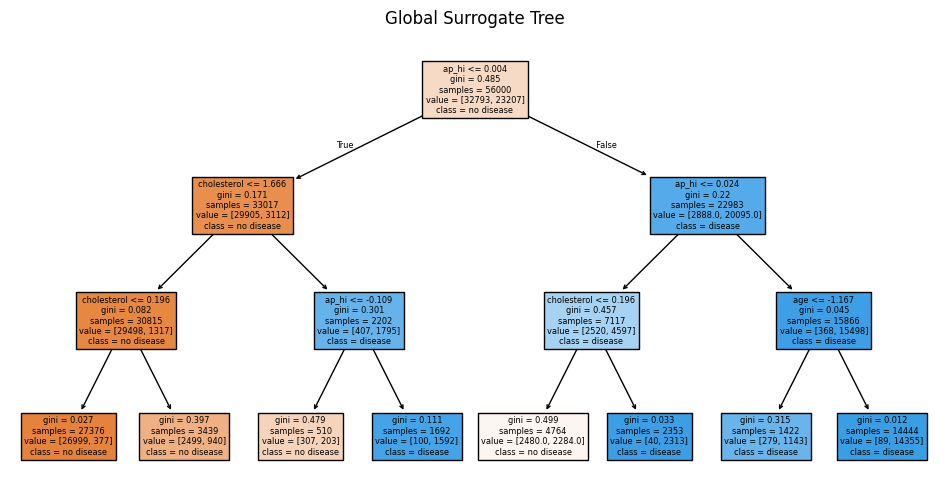

In [12]:
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree
import matplotlib.pyplot as plt

surrogate = DecisionTreeClassifier(max_depth=3, random_state=0)
surrogate.fit(x_train, y_trainPred)

plt.figure(figsize=(12, 6))
tree.plot_tree(surrogate, feature_names=x.columns, filled=True, class_names=["no disease", "disease"])
plt.title("Global Surrogate Tree")
plt.show()


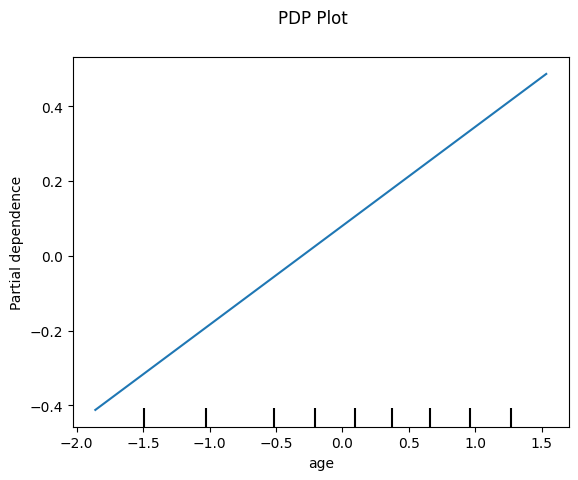

In [13]:
from sklearn.inspection import PartialDependenceDisplay


PartialDependenceDisplay.from_estimator(estimator=svmwith_linear,X=x_test,features=[0],feature_names=x.columns)
plt.suptitle("PDP Plot")
plt.show()



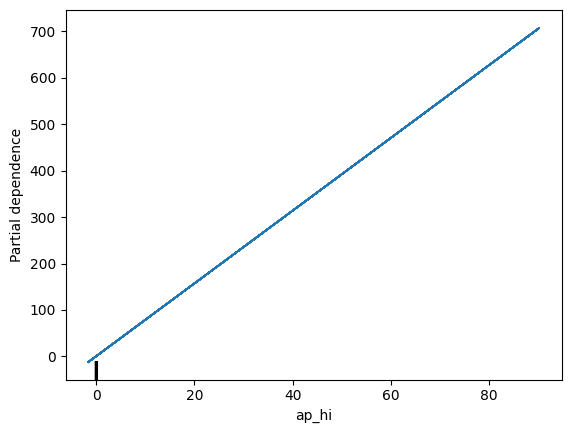

In [16]:

PartialDependenceDisplay.from_estimator(svmwith_linear,x_test,features=[4],feature_names=x.columns,kind="individual")

In [17]:
!pip install pyartemis

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 29.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/18.3 MB 85.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 97.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 293.3/293.3 kB 19.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 61.2 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
  Attempting uninstall: networkx
    Found existing installation: networkx 3.4.2
    Uninstalling networkx-3.4.2:
      Successfully uninstalled networkx-3.4.2
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pa

In [12]:
from artemis.interactions_methods.model_agnostic import FriedmanHStatisticMethod
import random

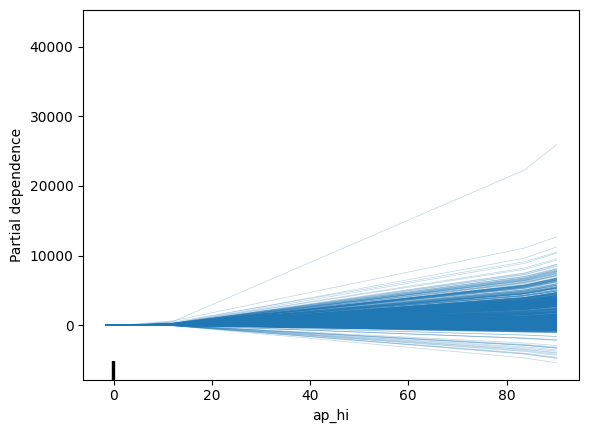

In [19]:
from sklearn.inspection import PartialDependenceDisplay

PartialDependenceDisplay.from_estimator(svmwith_poly,x_test,features=[4],feature_names=x.columns,kind="individual")